# Portfolio Allocation Across the Case Studies

**Docker image**: `ml4t`

The previous notebook traced the journey from signals to strategies. Here we
isolate the allocator layer: the same forecasts are routed through equal
weight, inverse-vol, MVO, risk parity and score-weighted allocators, and the
resulting Sharpe spread says how much room the allocator has to add or subtract
value once the signal is fixed.

A case study can only take part if it has a signal to hold fixed, meaning a
resolved spine prediction with allocation-stage backtests behind it. How many
do is a property of the current registry rather than a fixed number, so the
notebook reports it below instead of stating it here.

**Learning Objectives**:
- Compare allocator performance across diverse asset classes and frequencies
- Identify when allocation amplifies signal vs when signal is too weak to matter
- Examine the spread between best and worst allocators per case study

**Book Reference**: Chapter 20, Section 20.5 (Portfolio Allocation Across the Case Studies)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.
Each case study's registry must contain Ch17 allocation-stage backtests.

In [1]:
"""Ch20 Portfolio Allocation — spine-pinned allocator comparison across 8 case studies.

The Table 20.6 / Figure 20.14 semantics are: hold the highest-validation-Sharpe
signal carrier fixed per case study, then compare allocators at the allocation
stage only, so the best-minus-worst spread measures what the allocator alone
contributes (risk overlays are a downstream layer covered in §20.7). This
matches the caption "rank-1 signal held fixed" and the spine-pinning logic in
``case_studies.utils.strategy_analysis.build_all_synthesis``.
"""

import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    SHORT_NAMES,
    extract_allocator,
    is_unallocated,
    load_chapter_backtests,
)
from utils.paths import get_chapter_dir
from utils.style import show_with_alt

In [2]:
# 0 = all
MAX_CASE_STUDIES = 0

In [3]:
CS_LIST = CASE_STUDY_IDS[:MAX_CASE_STUDIES] if MAX_CASE_STUDIES else CASE_STUDY_IDS


def extract_top_k(spec_json: str) -> int:
    """Extract top_k from backtest spec."""
    spec = json.loads(spec_json)
    return spec.get("allocation", {}).get("top_k", 0) or spec.get("signal", {}).get("top_k", 0)

## Load Allocation Results from Registry

Ch17 backtests compare different allocation methods (equal weight, inverse
vol, MVO, risk parity, score-weighted, HRP) while holding the signal
constant. We load the `stage: "allocation"` runs and restrict to the spine
prediction_hash per case study so the comparison reads as
"best within the highest-validation-Sharpe signal configuration".

A case study absent from the selected configuration file is an error: `01_aggregate_synthesis`
writes a row for every case study it iterates, so a missing key means the file
is stale. A case study present with a *null* spine is different: its registry
holds no backtests to resolve one from. It is named and excluded. The check
below used to test only that the key existed, so a null passed it and then
dropped out silently at the filter, the outcome the check exists to prevent.

Universe size, used to size the bubbles much further down, comes from
`overview.parquet` rather than from a dict typed into this notebook. Every one
of that dict's nine entries had drifted from the shipped artifact - etfs 64
against 100, sp500_options 480 against 627, us_equities_panel 311 against 3199.

The spine prediction hash for each case study is read from the synthesis selection that
`01_aggregate_synthesis` writes. `backtest_comparison.parquet` is the canonical Chapter 20
artifact recording one spine prediction hash per case study.

In [4]:
_spine_df = pl.read_parquet(get_chapter_dir(20) / "output" / "backtest_comparison.parquet").select(
    "case_study_id", "spine_prediction_hash"
)
SPINE_BY_CS = dict(
    zip(
        _spine_df["case_study_id"].to_list(),
        _spine_df["spine_prediction_hash"].to_list(),
        strict=False,
    )
)

_missing_spine = [cs for cs in CS_LIST if cs not in SPINE_BY_CS]
if _missing_spine:
    msg = (
        f"No spine_prediction_hash in backtest_comparison.parquet for: "
        f"{_missing_spine}. Re-run 01_aggregate_synthesis to refresh the spine hashes."
    )
    raise RuntimeError(msg)

NO_SPINE = sorted(cs for cs in CS_LIST if SPINE_BY_CS.get(cs) is None)
if NO_SPINE:
    print(f"No resolved spine, excluded from the allocator comparison: {NO_SPINE}")

This section isolates the allocator layer: the signal is held fixed and only the allocation
method varies. It loads the allocation stage and nothing downstream of it. A trailing stop or
any other Chapter 19 risk overlay is a later layer, and including its Sharpe here would credit
the allocator with work the overlay did, which is not the measurement this section claims to
make. The "max across rebalance and top-K variants" in Table 20.6 is taken over
allocation-stage variants for the same reason.

In [5]:
combined_raw = load_chapter_backtests(
    "ch17",
    case_studies=CS_LIST,
    metrics=[
        "sharpe",
        "sortino",
        "total_return",
        "max_drawdown",
        "cagr",
        "volatility",
        "num_trades",
        "win_rate",
    ],
)

if combined_raw.is_empty():
    msg = "No allocation-stage backtest results found across case studies"
    raise RuntimeError(msg)

# Pin to spine prediction_hash per case study.
spine_filter = pl.struct(["case_study", "prediction_hash"]).map_elements(
    lambda row: row["prediction_hash"] == SPINE_BY_CS.get(row["case_study"]),
    return_dtype=pl.Boolean,
)
combined = combined_raw.filter(spine_filter)

# Extract allocator method and top_k from spec_json
comparison = (
    combined.with_columns(
        allocator=pl.col("spec_json").map_elements(extract_allocator, return_dtype=pl.Utf8),
        top_k=pl.col("spec_json").map_elements(extract_top_k, return_dtype=pl.Int64),
    )
    .filter(
        pl.col("allocator").is_in(
            [
                "equal_weight",
                "inverse_vol",
                "score_weighted",
                "mvo_ledoit_wolf",
                "risk_parity",
                "hrp",
                "conformal_weighted",
            ]
        )
    )
    .select(
        "case_study",
        pl.col("case_study").replace(SHORT_NAMES).alias("display_name"),
        "label",
        "allocator",
        "top_k",
        "sharpe",
        "sortino",
        "total_return",
        "max_drawdown",
        "cagr",
        "volatility",
        "num_trades",
    )
)

# Collapse to one row per (case_study, allocator) — keep the configuration
# (rebalance / top_k / overlay) that posts the highest Sharpe. Table 20.6
# entries are the "best for that allocator" within the spine configuration.
#
# A backtest with no Sharpe is dropped rather than ranked. It is not a worse result, it is an
# unmeasured one, and polars sorts nulls FIRST under `descending=True` unless told otherwise -
# so `keep="first"` would hand every table below the row that has no number. `nulls_last=True`
# on each ranking says the same thing a second time, for a column this filter does not cover.
comparison = comparison.filter(pl.col("sharpe").is_not_null())
comparison = comparison.sort("sharpe", descending=True, nulls_last=True).unique(
    subset=["case_study", "allocator"], keep="first"
)

n_cs = comparison["case_study"].n_unique()
print(
    f"Allocators × case studies (spine-pinned): {len(comparison)} rows across {n_cs} case studies"
)
comparison.head(10)

Allocators × case studies (spine-pinned): 44 rows across 8 case studies


case_study,display_name,label,allocator,top_k,sharpe,sortino,total_return,max_drawdown,cagr,volatility,num_trades
str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""crypto_perps_funding""","""Crypto""","""fwd_ret_24h""","""inverse_vol""",0,-0.012423,-0.016692,-0.393192,-0.762222,-0.221288,0.689495,3140.0
"""sp500_options""","""SP500 Options""","""ret_to_expiry""","""mvo_ledoit_wolf""",0,-0.157599,-0.189365,-0.409272,-0.77703,-0.244556,0.594061,null
"""sp500_options""","""SP500 Options""","""ret_to_expiry""","""inverse_vol""",0,-0.263264,-0.314247,-0.474182,-0.776605,-0.289982,0.592744,null
"""us_equities_panel""","""US Equities""","""fwd_ret_1d""","""score_weighted""",0,-0.057672,-0.083591,-0.846829,-0.950142,-0.107678,0.423795,120763.0
"""us_equities_panel""","""US Equities""","""fwd_ret_1d""","""risk_parity""",0,-0.882425,-1.197031,-0.993046,-0.995243,-0.260436,0.292967,119289.0
"""fx_pairs""","""FX""","""fwd_ret_21d""","""hrp""",0,0.187467,0.266879,0.066341,-0.075453,0.007955,0.048548,387.0
"""sp500_options""","""SP500 Options""","""ret_to_expiry""","""hrp""",0,-0.434049,-0.512471,-0.56698,-0.777946,-0.35976,0.593511,null
"""etfs""","""ETFs""","""fwd_ret_5d""","""score_weighted""",0,0.394962,0.549727,0.697726,-0.441738,0.068575,0.243512,2996.0
"""fx_pairs""","""FX""","""fwd_ret_21d""","""score_weighted""",0,0.309146,0.445778,0.148671,-0.103072,0.017244,0.061397,376.0


## Highest-Sharpe Allocator by Case Study

Which allocation method achieves the highest Sharpe for each dataset?

In [6]:
best_per_cs = (
    comparison.sort("sharpe", descending=True, nulls_last=True)
    .unique(subset=["case_study"], keep="first")
    .select(
        "display_name",
        "label",
        "allocator",
        "top_k",
        "sharpe",
        "sortino",
        "total_return",
        "max_drawdown",
    )
    .sort("sharpe", descending=True, nulls_last=True)
)
print("Best allocator per case study (sorted by Sharpe):\n")
best_per_cs

Best allocator per case study (sorted by Sharpe):



display_name,label,allocator,top_k,sharpe,sortino,total_return,max_drawdown
str,str,str,i64,f64,f64,f64,f64
"""US Firms""","""fwd_ret_1m_win""","""score_weighted""",0,3.582869,13.769535,1059.65267,-0.177018
"""SP500 Eq+Opt""","""fwd_ret_risk_adj_5d""","""hrp""",0,1.861823,2.934199,1.698541,-0.254433
"""ETFs""","""fwd_ret_5d""","""hrp""",0,0.876946,1.31822,1.786508,-0.226398
"""Crypto""","""fwd_ret_24h""","""mvo_ledoit_wolf""",0,0.827553,1.345006,0.924375,-0.585632
"""CME Futures""","""fwd_ret_21d""","""conformal_weighted""",0,0.790071,1.19982,0.478409,-0.167118
"""FX""","""fwd_ret_21d""","""score_weighted""",0,0.309146,0.445778,0.148671,-0.103072
"""US Equities""","""fwd_ret_1d""","""score_weighted""",0,-0.057672,-0.083591,-0.846829,-0.950142
"""SP500 Options""","""ret_to_expiry""","""score_weighted""",0,-0.102046,-0.122495,-0.371676,-0.775968


## Sharpe by Allocator (Bar Chart)

A direct visual comparison of each allocator's best Sharpe across case studies.

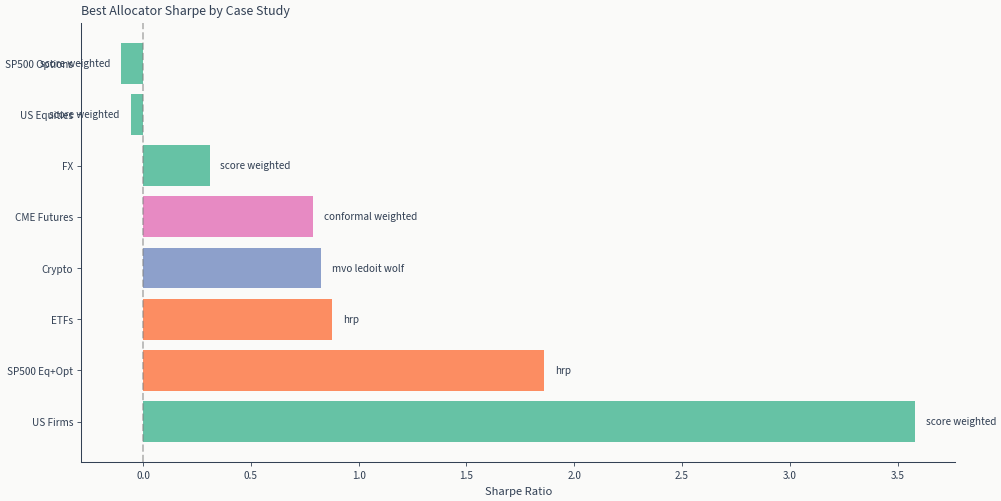

In [7]:
best_data = best_per_cs.to_pandas()

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {}
color_cycle = plt.cm.Set2.colors
for i, alloc in enumerate(best_data["allocator"].unique()):
    colors_map[alloc] = color_cycle[i % len(color_cycle)]

bars = ax.barh(
    best_data["display_name"],
    best_data["sharpe"],
    color=[colors_map.get(a, "steelblue") for a in best_data["allocator"]],
)
ax.set_xlabel("Sharpe Ratio")
ax.set_title("Best Allocator Sharpe by Case Study")
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)

for bar, alloc in zip(bars, best_data["allocator"], strict=False):
    x_pos = bar.get_width()
    ax.text(
        x_pos + 0.05 if x_pos >= 0 else x_pos - 0.05,
        bar.get_y() + bar.get_height() / 2,
        alloc.replace("_", " "),
        va="center",
        ha="left" if x_pos >= 0 else "right",
        fontsize=8,
    )

show_with_alt(
    fig,
    "Bar chart of the highest Sharpe reached by any allocator in each case "
    "study, ordered by that Sharpe, with a reference line at zero.",
)

**Reading the chart**: one horizontal bar per case study, whose length is the Sharpe of that
case study's best allocator and whose label and colour name which allocator that was. Bars
are sorted by Sharpe, with a reference line at zero. Because each bar is already a maximum
over allocators, the chart compares case studies and says nothing about how much the
allocator choice was worth within one; the heatmap below reports every allocator per case
study and is where that comparison is read.

## Equal-Weight Baseline vs Best Allocator

How much does allocation choice improve over the simplest baseline?

The baseline is read from the **signal** stage, not from an `equal_weight` allocator.
`equal_weight` left every case study's allocator menu on the ruling that equal weight IS the
baseline and listing it as an alternative re-runs the baseline as its own competitor
(`reference/CASE_STUDY_PIPELINE.md` section 4). Measured 2026-09-18, all nine registries hold
zero `equal_weight` rows at `stage='allocation'`, so the filter this section used to apply
matched nothing and every case study's `ew_sharpe`, `sharpe_diff` and `pct_improvement` came
out null - the section reported no number at all. Doing no allocation work is recorded one
stage earlier, on the same spine prediction, which is what `is_unallocated` selects.

In [8]:
_signal_spine = load_chapter_backtests("ch16", case_studies=CS_LIST, metrics=["sharpe"]).filter(
    spine_filter
)
ew_sharpes = (
    _signal_spine.filter(
        pl.col("sharpe").is_not_null()
        & pl.col("spec_json").map_elements(is_unallocated, return_dtype=pl.Boolean)
    )
    .group_by("case_study")
    .agg(ew_sharpe=pl.col("sharpe").max())
)

best_sharpes = (
    comparison.sort("sharpe", descending=True, nulls_last=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", best_sharpe=pl.col("sharpe"), best_allocator=pl.col("allocator"))
)

improvement = (
    best_sharpes.join(ew_sharpes, on="case_study", how="left")
    .with_columns(
        display_name=pl.col("case_study").replace(SHORT_NAMES),
        sharpe_diff=pl.col("best_sharpe") - pl.col("ew_sharpe"),
    )
    .with_columns(
        # Null, not zero, where there is no equal-weight run to improve on. A
        # zero reads as "the allocator changed nothing", which is a measurement;
        # a missing baseline is the absence of one.
        pct_improvement=pl.when(pl.col("ew_sharpe").abs() > 0.001)
        .then((pl.col("sharpe_diff") / pl.col("ew_sharpe").abs()) * 100)
        .otherwise(None),
    )
    .sort("sharpe_diff", descending=True)
)
print("Sharpe improvement from equal-weight to best allocator:\n")
improvement.select(
    "display_name", "ew_sharpe", "best_sharpe", "best_allocator", "sharpe_diff", "pct_improvement"
)

Sharpe improvement from equal-weight to best allocator:



display_name,ew_sharpe,best_sharpe,best_allocator,sharpe_diff,pct_improvement
str,f64,f64,str,f64,f64
"""SP500 Eq+Opt""",1.600317,1.861823,"""hrp""",0.261506,16.340913
"""ETFs""",0.649554,0.876946,"""hrp""",0.227392,35.007482
"""FX""",0.202385,0.309146,"""score_weighted""",0.106761,52.751157
"""SP500 Options""",-0.157599,-0.102046,"""score_weighted""",0.055553,35.249761
"""US Firms""",3.557338,3.582869,"""score_weighted""",0.025531,0.717705
"""CME Futures""",0.985849,0.790071,"""conformal_weighted""",-0.195778,-19.858831
"""Crypto""",1.555554,0.827553,"""mvo_ledoit_wolf""",-0.728001,-46.800121
"""US Equities""",1.052785,-0.057672,"""score_weighted""",-1.110457,-105.478053


In [9]:
_with_ew = improvement.filter(pl.col("ew_sharpe").is_not_null())
_without = improvement.filter(pl.col("ew_sharpe").is_null())
display(
    Markdown(
        f"{_with_ew.height} of {improvement.height} case studies in this "
        "comparison carry a signal-stage equal-weight baseline on the spine "
        "prediction, so only those can be measured against it"
        + (
            f". The rest ({', '.join(_without['display_name'].to_list())}) have "
            "a highest-Sharpe allocator but nothing to compare it with, and are "
            "left blank rather than credited with a zero improvement"
            if _without.height
            else ""
        )
        + "."
        + (
            (
                " In every one of them the highest-Sharpe allocator is equal "
                "weight itself, so no alternative improved on the baseline."
                if (_with_ew["sharpe_diff"].abs() < 1e-9).all()
                else f" Where the comparison can be made, the change ranges from "
                f"{_with_ew['sharpe_diff'].min():+.3f} to "
                f"{_with_ew['sharpe_diff'].max():+.3f} Sharpe."
            )
            if _with_ew.height
            else ""
        )
    )
)

8 of 8 case studies in this comparison carry a signal-stage equal-weight baseline on the spine prediction, so only those can be measured against it. Where the comparison can be made, the change ranges from -1.110 to +0.262 Sharpe.

## Allocator Performance Heatmap

Visualize which allocators appear across case studies and their relative performance.

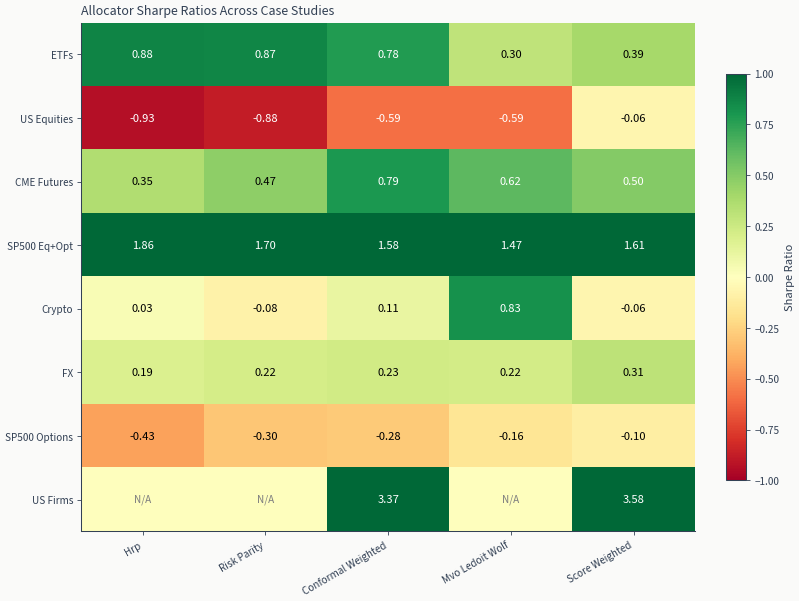

In [10]:
# Find the most common allocators
alloc_counts = comparison.group_by("allocator").agg(n=pl.len()).sort("n", descending=True)
common_allocators = alloc_counts.head(5)["allocator"].to_list()

heatmap_data = (
    comparison.filter(pl.col("allocator").is_in(common_allocators))
    .group_by("display_name", "allocator")
    .agg(sharpe=pl.col("sharpe").max())
    .pivot(on="allocator", index="display_name", values="sharpe")
)

cs_names = heatmap_data["display_name"].to_list()
alloc_cols = [c for c in heatmap_data.columns if c != "display_name"]
data_matrix = heatmap_data.select(alloc_cols).to_numpy()
mask = np.isnan(data_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    np.where(mask, 0, data_matrix),
    cmap="RdYlGn",
    aspect="auto",
    vmin=-1,
    vmax=1,
)

for i in range(len(cs_names)):
    for j in range(len(alloc_cols)):
        val = data_matrix[i, j]
        if not np.isnan(val):
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)
        else:
            ax.text(j, i, "N/A", ha="center", va="center", color="gray", fontsize=8)

ax.set_xticks(range(len(alloc_cols)))
ax.set_xticklabels([a.replace("_", " ").title() for a in alloc_cols], rotation=30, ha="right")
ax.set_yticks(range(len(cs_names)))
ax.set_yticklabels(cs_names)
ax.set_title("Allocator Sharpe Ratios Across Case Studies")
fig.colorbar(im, ax=ax, label="Sharpe Ratio", shrink=0.8)
show_with_alt(
    fig,
    "Heatmap with one row per case study and one column per allocator, each cell "
    "annotated with that pair's Sharpe and coloured red through green over the "
    "range minus one to one, with untested pairs marked N/A.",
)

**Reading the heatmap**: one row per case study, one column per allocator, coloured by
Sharpe. A missing cell (N/A) means that allocator was not tested on that dataset -
strategy-specific constraints such as long-only or no-shorting exclude certain methods - and
is a different thing from a cell whose Sharpe is near zero. Read across a row for how much
the allocator choice moved that case study, and down a column for whether one allocator
behaves consistently across markets.

## Signal Strength vs Allocation Impact

Does allocation choice matter more when the underlying signal is strong?
We compare the spread between best and worst allocator Sharpe per case study.

In [11]:
spread_df = (
    comparison.group_by("case_study")
    .agg(
        display_name=pl.col("display_name").first(),
        best_sharpe=pl.col("sharpe").max(),
        worst_sharpe=pl.col("sharpe").min(),
        n_allocators=pl.col("allocator").n_unique(),
    )
    .with_columns(spread=pl.col("best_sharpe") - pl.col("worst_sharpe"))
    .sort("spread", descending=True)
)
print("Allocator Sharpe spread (best - worst) per case study:\n")
spread_df.select("display_name", "best_sharpe", "worst_sharpe", "spread", "n_allocators")

Allocator Sharpe spread (best - worst) per case study:



display_name,best_sharpe,worst_sharpe,spread,n_allocators
str,f64,f64,f64,u32
"""Crypto""",0.827553,-0.080904,0.908457,6
"""US Equities""",-0.057672,-0.931217,0.873545,6
"""ETFs""",0.876946,0.29911,0.577836,6
"""CME Futures""",0.790071,0.354759,0.435312,6
"""SP500 Eq+Opt""",1.861823,1.469169,0.392654,6
"""SP500 Options""",-0.102046,-0.434049,0.332003,6
"""US Firms""",3.582869,3.369284,0.213585,2
"""FX""",0.309146,0.187467,0.121678,6


**Interpretation**: The highest-minus-lowest spread is the cleanest summary of
allocator sensitivity. Wide spreads indicate that portfolio construction is
load-bearing for that dataset, while tight spreads indicate that upstream
signal quality dominates method choice.

## Summary Statistics

In [12]:
positive = spread_df.filter(pl.col("best_sharpe") > 0).height
total = spread_df.height

print(f"""
=== Cross-Dataset Allocation Summary ===
Case studies loaded:    {n_cs}
Total allocator combos: {len(comparison)}

--- Signal Quality ---""")

for row in spread_df.iter_rows(named=True):
    cs = row["display_name"]
    best = row["best_sharpe"]
    spread = row["spread"]
    print(f"  {cs:20s}  Best SR: {best:+.2f}  Spread: {spread:.3f}")

print("\n--- Key Findings ---")
print(f"- Positive best Sharpe in {positive}/{total} case studies")
if spread_df.height > 0:
    widest = spread_df.row(0, named=True)
    tightest = spread_df.sort("spread").row(0, named=True)
    print(
        f"- Largest allocation sensitivity: {widest['display_name']} (spread={widest['spread']:.3f})"
    )
    print(
        f"- Smallest allocation sensitivity: {tightest['display_name']} "
        f"(spread={tightest['spread']:.3f})"
    )
print("- No single allocator has the highest Sharpe in every case study")


=== Cross-Dataset Allocation Summary ===
Case studies loaded:    8
Total allocator combos: 44

--- Signal Quality ---
  Crypto                Best SR: +0.83  Spread: 0.908
  US Equities           Best SR: -0.06  Spread: 0.874
  ETFs                  Best SR: +0.88  Spread: 0.578
  CME Futures           Best SR: +0.79  Spread: 0.435
  SP500 Eq+Opt          Best SR: +1.86  Spread: 0.393
  SP500 Options         Best SR: -0.10  Spread: 0.332
  US Firms              Best SR: +3.58  Spread: 0.214
  FX                    Best SR: +0.31  Spread: 0.122

--- Key Findings ---
- Positive best Sharpe in 6/8 case studies
- Largest allocation sensitivity: Crypto (spread=0.908)
- Smallest allocation sensitivity: FX (spread=0.122)
- No single allocator has the highest Sharpe in every case study


## Uplift Breadth: Is Allocation Improvement Broad or Narrow?

A practitioner needs to know: is the allocation improvement driven by
one lucky combination, or do most allocators improve over the baseline?
Narrow uplift (only one allocator helps) is less reliable than broad
uplift (most allocators improve).

In [13]:
breadth_rows = []
_EW_BY_CS = dict(zip(ew_sharpes["case_study"], ew_sharpes["ew_sharpe"], strict=True))
for cs_id in comparison["case_study"].unique().sort().to_list():
    # The baseline comes from `ew_sharpes` (signal stage) for the same reason as above: no
    # case study runs `equal_weight` as an allocator, so reading it out of `comparison` left
    # every case study skipped and the breadth table empty.
    ew_sr = _EW_BY_CS.get(cs_id)
    if ew_sr is None:
        continue
    non_ew = comparison.filter(pl.col("case_study") == cs_id)
    if non_ew.is_empty():
        continue
    n_better = non_ew.filter(pl.col("sharpe") > ew_sr).height
    n_total = non_ew.height
    breadth_rows.append(
        {
            "case_study": cs_id,
            "display_name": SHORT_NAMES.get(cs_id, cs_id),
            "ew_sharpe": round(ew_sr, 3),
            "n_allocators_tested": n_total,
            "n_beat_ew": n_better,
            "pct_beat_ew": round(100 * n_better / n_total, 0) if n_total > 0 else 0,
            # "narrow" used to absorb the zero case, labelling "one or two
            # allocators beat the baseline" and "none did" identically.
            "breadth": "none"
            if n_better == 0
            else "broad"
            if n_better / max(n_total, 1) > 0.5
            else "moderate"
            if n_better / max(n_total, 1) > 0.25
            else "narrow",
        }
    )

breadth = (
    pl.DataFrame(breadth_rows).sort("pct_beat_ew", descending=True)
    if breadth_rows
    else pl.DataFrame()
)

In [14]:
if not breadth.is_empty():
    print("=== Allocation Uplift Breadth ===")
    print(
        breadth.select(
            "display_name",
            "ew_sharpe",
            "n_beat_ew",
            "n_allocators_tested",
            "pct_beat_ew",
            "breadth",
        )
    )

    for _label in ("broad", "moderate", "narrow", "none"):
        _n = breadth.filter(pl.col("breadth") == _label).height
        if _n:
            print(f"\n{_label} uplift: {_n}/{breadth.height}")
    _n_compared = comparison["case_study"].n_unique()
    if breadth.height < _n_compared:
        _dropped = sorted(set(comparison["case_study"].unique()) - set(breadth["case_study"]))
        print(
            f"\nExcluded for having no equal-weight run to compare against "
            f"({len(_dropped)} of {_n_compared}): "
            + ", ".join(SHORT_NAMES.get(c, c) for c in _dropped)
        )
else:
    print("No case study has both an equal-weight run and an alternative to compare it with.")

=== Allocation Uplift Breadth ===
shape: (8, 6)
┌───────────────┬───────────┬───────────┬─────────────────────┬─────────────┬──────────┐
│ display_name  ┆ ew_sharpe ┆ n_beat_ew ┆ n_allocators_tested ┆ pct_beat_ew ┆ breadth  │
│ ---           ┆ ---       ┆ ---       ┆ ---                 ┆ ---         ┆ ---      │
│ str           ┆ f64       ┆ i64       ┆ i64                 ┆ f64         ┆ str      │
╞═══════════════╪═══════════╪═══════════╪═════════════════════╪═════════════╪══════════╡
│ FX            ┆ 0.202     ┆ 5         ┆ 6                   ┆ 83.0        ┆ broad    │
│ ETFs          ┆ 0.65      ┆ 4         ┆ 6                   ┆ 67.0        ┆ broad    │
│ SP500 Eq+Opt  ┆ 1.6       ┆ 4         ┆ 6                   ┆ 67.0        ┆ broad    │
│ US Firms      ┆ 3.557     ┆ 1         ┆ 2                   ┆ 50.0        ┆ moderate │
│ SP500 Options ┆ -0.158    ┆ 1         ┆ 6                   ┆ 17.0        ┆ narrow   │
│ CME Futures   ┆ 0.986     ┆ 0         ┆ 6                   

**Interpretation**: "Broad" means most non-EW allocators improve over
equal weight, so the uplift does not depend on which one was chosen. "Narrow"
means only one or two exceed the baseline, so the improvement is the choice.
"None" means no alternative beat equal weight at all, which is a different
result again and was previously reported as "narrow". This matters for Ch20:
broad uplift
is more trustworthy as a real improvement; narrow uplift could be
selection bias.

## When Does Allocation Optimization Help?

The previous sections report allocation uplift per dataset. Here we ask the
structural question: **what predicts whether optimization helps?** We
hypothesize two factors:

- **Signal strength** (EW baseline Sharpe): When the signal is strong,
  most allocators produce positive returns — optimization adds little.
- **Universe size**: In broad universes, allocation determines
  concentration; in narrow ones, top-$k$ selection dominates.

The scatter below tests this hypothesis, wherever enough case studies have both an
allocation uplift and a signal-stage equal-weight baseline on the spine prediction to place a
point. When they do not, the cell says which ones qualified instead of drawing it.

The structural features for the "when MVO helps" question come next. The equal-weight
baseline they measure uplift against is the signal stage on the spine prediction - the same
`ew_sharpes` the comparison above uses - so the uplift is over doing no allocation work at
all on the configuration the case study reports. Taking the best baseline across every
prediction instead would let the uplift absorb a change of model or label, because
`best_alloc` below is pinned to the spine and the difference of the two would no longer be
the allocator's contribution.

In [15]:
UNIVERSE_SIZES = dict(
    pl.read_parquet(get_chapter_dir(20) / "output" / "overview.parquet")
    .select("cs_id", "universe")
    .iter_rows()
)

In [16]:
# Best allocator Sharpe per CS from Ch17
best_alloc = (
    comparison.sort("sharpe", descending=True, nulls_last=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", best_sharpe=pl.col("sharpe"))
)

mvo_data = best_alloc.join(ew_sharpes, on="case_study", how="inner").with_columns(
    display_name=pl.col("case_study").replace(SHORT_NAMES),
    uplift=pl.col("best_sharpe") - pl.col("ew_sharpe"),
)

mvo_rows = []
for row in mvo_data.iter_rows(named=True):
    mvo_rows.append(
        {
            "case_study": row["case_study"],
            "display_name": row["display_name"],
            "ew_sharpe": float(row["ew_sharpe"]),
            "best_sharpe": float(row["best_sharpe"]),
            "uplift": float(row["uplift"]),
            "universe_size": UNIVERSE_SIZES.get(row["case_study"], 0),
        }
    )

# The schema is declared so an empty result is still a frame with these columns: a bare
# `pl.DataFrame([])` has none, and the cells below then raise ColumnNotFoundError on
# `ew_sharpe` instead of reporting that nothing qualified.
mvo_df = pl.DataFrame(
    mvo_rows,
    schema={
        "case_study": pl.Utf8,
        "display_name": pl.Utf8,
        "ew_sharpe": pl.Float64,
        "best_sharpe": pl.Float64,
        "uplift": pl.Float64,
        "universe_size": pl.Int64,
    },
)

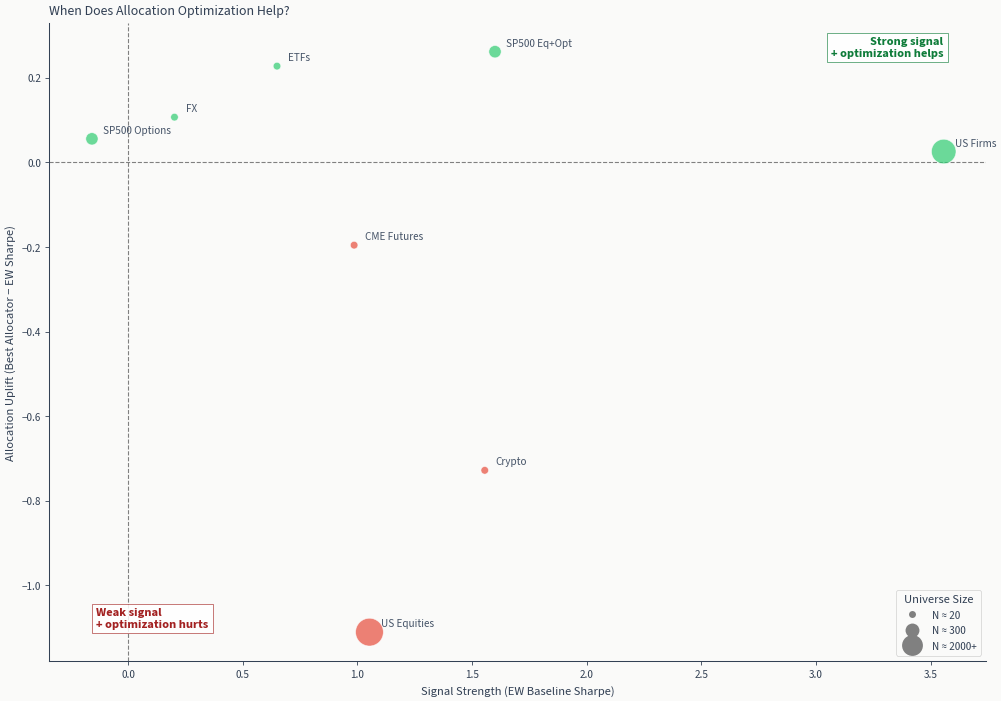

In [17]:
# Scatter plot: signal strength vs allocation uplift
if mvo_df.height >= 3:
    fig, ax = plt.subplots(figsize=(10, 7))

    ew_vals = mvo_df["ew_sharpe"].to_list()
    uplift_vals = mvo_df["uplift"].to_list()
    sizes = [max(30, n / 8) for n in mvo_df["universe_size"].to_list()]
    names = mvo_df["display_name"].to_list()

    # Color by whether uplift is positive
    colors = ["#2ecc71" if u > 0 else "#e74c3c" for u in uplift_vals]

    ax.scatter(ew_vals, uplift_vals, s=sizes, c=colors, alpha=0.7, edgecolors="white", zorder=5)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

    for name, x, y in zip(names, ew_vals, uplift_vals, strict=False):
        ax.annotate(
            name,
            (x, y),
            textcoords="offset points",
            xytext=(8, 4),
            fontsize=8,
            color="#475569",
        )

    ax.set_xlabel("Signal Strength (EW Baseline Sharpe)")
    ax.set_ylabel("Allocation Uplift (Best Allocator − EW Sharpe)")
    ax.set_title("When Does Allocation Optimization Help?")

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.text(
        xlim[1] * 0.95,
        ylim[1] * 0.9,
        "Strong signal\n+ optimization helps",
        ha="right",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#0f7c3a",
        bbox={"facecolor": "white", "edgecolor": "#0f7c3a", "alpha": 0.85, "pad": 3},
    )
    ax.text(
        xlim[0] + (xlim[1] - xlim[0]) * 0.05,
        ylim[0] + (ylim[1] - ylim[0]) * 0.05,
        "Weak signal\n+ optimization hurts",
        ha="left",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#a32222",
        bbox={"facecolor": "white", "edgecolor": "#a32222", "alpha": 0.85, "pad": 3},
    )

    from matplotlib.lines import Line2D

    size_legend = [
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=5, label="N ≈ 20"),
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=10, label="N ≈ 300"),
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=15, label="N ≈ 2000+"),
    ]
    ax.legend(
        handles=size_legend,
        title="Universe Size",
        loc="lower right",
        fontsize=8,
        frameon=True,
        framealpha=0.9,
    )

    show_with_alt(
        fig,
        "Scatter of allocation uplift against the equal-weight baseline Sharpe, "
        "one bubble per case study sized by universe size and labelled by name, "
        "with quadrant annotations naming the four possible regimes.",
    )
else:
    print(
        f"The uplift-against-baseline scatter needs at least three case studies with both an "
        f"allocation uplift and a signal-stage equal-weight baseline on the spine prediction; "
        f"{mvo_df.height} qualified "
        f"({', '.join(mvo_df['display_name'].to_list()) or 'none'}). That is an absent "
        f"measurement rather than a negative result."
    )

In [18]:
def uplift_interpretation(mvo_df: pl.DataFrame) -> str:
    """What the scatter shows, read off the frame rather than asserted.

    An earlier version said every point sat in one region, that no weak-signal case study
    reached the comparison, and that the chart was a template awaiting a rebuild. That
    described the single point the broken equal-weight filter used to leave, and the cell went
    on printing it once there were eight. Each sentence here is therefore conditioned on the
    frame that produced it, and `MAX_CASE_STUDIES` makes the awkward frames reachable rather
    than hypothetical:

    * the extremes come from the helped and hurt subsets separately, so one observation is
      never both the largest gain and the largest loss;
    * an uplift of exactly zero is in neither subset, so it is counted and named rather than
      folded into one of them, and "every" is used only where a subset covers the whole frame;
    * the closing claim needs both signs present, and where the two subsets' baselines are
      disjoint it reports which way round the separation runs, because the hypothesis below
      predicts one direction and the reverse would contradict it.
    """
    if not mvo_df.height:
        return "None qualified, so there is no range to report and the plane is empty."

    helped = mvo_df.filter(pl.col("uplift") > 0)
    hurt = mvo_df.filter(pl.col("uplift") < 0)
    unchanged = mvo_df.height - helped.height - hurt.height
    quadrants = {(row["ew_sharpe"] > 0, row["uplift"] > 0) for row in mvo_df.iter_rows(named=True)}

    tally = f"Allocation helps in {helped.height} of them and hurts in {hurt.height}"
    tally += f", and changes nothing in {unchanged}." if unchanged else "."
    lines = [
        f"Their baselines run from {mvo_df['ew_sharpe'].min():+.2f} to "
        f"{mvo_df['ew_sharpe'].max():+.2f} Sharpe and their uplifts from "
        f"{mvo_df['uplift'].min():+.2f} to {mvo_df['uplift'].max():+.2f}, "
        f"occupying {len(quadrants)} of the four quadrants.",
        tally,
    ]
    if helped.height:
        best = helped.sort("uplift", descending=True).row(0, named=True)
        lines.append(
            f"The largest gain is {best['display_name']} at {best['uplift']:+.2f} on a "
            f"{best['ew_sharpe']:+.2f} baseline."
        )
    if hurt.height:
        worst = hurt.sort("uplift").row(0, named=True)
        lines.append(
            f"The largest loss is {worst['display_name']} at {worst['uplift']:+.2f} on a "
            f"{worst['ew_sharpe']:+.2f} baseline."
        )

    if helped.height and hurt.height:
        if (
            helped["ew_sharpe"].min() <= hurt["ew_sharpe"].max()
            and hurt["ew_sharpe"].min() <= helped["ew_sharpe"].max()
        ):
            lines.append(
                "The two groups' baselines overlap, so baseline strength does not separate "
                "them and the sign of the uplift is not decided by it alone - which is what "
                "the hypothesis below would need."
            )
        elif helped["ew_sharpe"].max() < hurt["ew_sharpe"].min():
            lines.append(
                "Every case study allocation helps has a weaker baseline than every one it "
                "hurts, which is the direction the hypothesis below predicts; whether that is "
                "the mechanism or the small number of points is not decidable from these."
            )
        else:
            lines.append(
                "Every case study allocation helps has a stronger baseline than every one it "
                "hurts, which is the opposite of what the hypothesis below predicts; these "
                "points are too few to weigh against it, but they do not support it."
            )
    else:
        if helped.height == mvo_df.height:
            seen = "helps in every case study here"
        elif hurt.height == mvo_df.height:
            seen = "hurts in every case study here"
        elif unchanged == mvo_df.height:
            seen = "changes nothing in any case study here"
        elif helped.height:
            seen = "never hurts here"
        else:
            seen = "never helps here"
        lines.append(
            f"Allocation {seen}, so these points cannot say whether the sign of the uplift "
            "depends on the strength of the baseline."
        )
    return f"{lines[0]}\n\n" + " ".join(lines[1:])

In [19]:
display(
    Markdown(
        f"The scatter carries {mvo_df.height} case studies: only those with both "
        "a signal-stage equal-weight baseline and Ch17 allocation backtests on the spine "
        f"prediction qualify. {uplift_interpretation(mvo_df)}"
    )
)

The scatter carries 8 case studies: only those with both a signal-stage equal-weight baseline and Ch17 allocation backtests on the spine prediction qualify. Their baselines run from -0.16 to +3.56 Sharpe and their uplifts from -1.11 to +0.26, occupying 3 of the four quadrants.

Allocation helps in 5 of them and hurts in 3. The largest gain is SP500 Eq+Opt at +0.26 on a +1.60 baseline. The largest loss is US Equities at -1.11 on a +1.05 baseline. The two groups' baselines overlap, so baseline strength does not separate them and the sign of the uplift is not decided by it alone - which is what the hypothesis below would need.

The mechanism the chart is meant to test: an allocator can only redistribute capital across
whatever the signal ranked, so when the ranking carries little information the allocator is
redistributing noise, and a method with more free parameters has more ways to fit that
noise. The scatter above is the evidence for it, and `uplift_interpretation` reads off what
these points can and cannot say about it rather than asserting either.

## Key Takeaways

The allocator that wins in each case study, and by how much over equal weight,
are properties of this registry. They are computed below. An earlier version of
this section typed them out, and named a leading allocator for six case studies
that have no allocation-stage backtests at all.

In [20]:
_wins = best_sharpes.group_by("best_allocator").len().sort("len", descending=True)
_spread_now = spread_df.sort("spread", descending=True)
_wide, _tight = _spread_now.row(0, named=True), _spread_now.row(-1, named=True)
display(
    Markdown(
        "**Which allocator posts the highest Sharpe**: "
        + ", ".join(f"{r['best_allocator']} ({r['len']})" for r in _wins.iter_rows(named=True))
        + f", across {best_sharpes.height} case studies. "
        + (
            "No allocator wins everywhere."
            if _wins.height > 1
            else "One allocator wins in all of them, which at this sample size is "
            "not evidence that it generally does."
        )
        + f"\n\n**Allocator sensitivity** (highest minus lowest Sharpe within a "
        f"case study) runs from {_tight['spread']:.3f} ({_tight['display_name']}, "
        f"{_tight['n_allocators']} allocators) to {_wide['spread']:.3f} "
        f"({_wide['display_name']}, {_wide['n_allocators']} allocators). Where the "
        "spread is small, the choice of allocator is not what determines the "
        "result; where it is large, it is a decision that has to be made on "
        "validation data and carries the selection risk that implies."
    )
)

**Which allocator posts the highest Sharpe**: score_weighted (4), hrp (2), mvo_ledoit_wolf (1), conformal_weighted (1), across 8 case studies. No allocator wins everywhere.

**Allocator sensitivity** (highest minus lowest Sharpe within a case study) runs from 0.122 (FX, 6 allocators) to 0.908 (Crypto, 6 allocators). Where the spread is small, the choice of allocator is not what determines the result; where it is large, it is a decision that has to be made on validation data and carries the selection risk that implies.

What holds independently of the registry:

- **Allocation cannot manufacture a signal.** Every allocator reads the same
  ranking; if the ranking is uninformative, redistributing capital across it
  changes the variance of the result and not its expectation.
- **The spread between allocators is itself the useful number.** A case study
  where every allocator lands in the same place is one where this decision can
  be made on grounds other than backtested Sharpe - turnover, capacity,
  explicability. A case study with a wide spread is one where the decision was
  made by looking at validation results, and should be treated accordingly.
- **Equal weight is the baseline worth beating**, because it has no parameters
  to fit and therefore nothing to overfit. An allocator that does not clear it
  has bought estimation risk for nothing.

## Known Limitations

- Only case studies with a resolved spine prediction take part, and the count
  is printed at the top of the notebook. The rest are mid-rebuild.
- Every Sharpe here is measured on validation folds. The allocator was chosen
  by looking at these numbers, so the spread between allocators overstates what
  the choice is worth out of sample by an amount this notebook does not
  estimate.
- Each allocator is represented by its own highest-Sharpe configuration across
  rebalance and top-k variants, so the comparison is between maxima and each is
  inflated by however many variants stood behind it.

**Next**: [`06_cost_survival`](06_cost_survival.ipynb) translates the same
allocator choices into cost-adjusted performance.